Total run time: 6.8922079990 ms
Average time difference (Normal / Improved): 28.3979002503 times


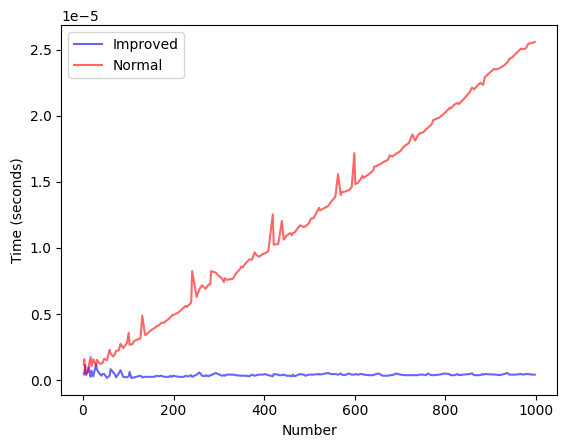

In [15]:
from concurrent.futures import ThreadPoolExecutor
from math import isqrt
from time import perf_counter

import matplotlib.pyplot as plt


def is_prime_improve(num: int) -> bool:
    if num <= 1:
        return False
    if num <= 3:
        return True
    if num % 2 == 0 or num % 3 == 0:
        return False

    limit = isqrt(num)
    i = 5
    while i <= limit:
        if num % i == 0 or num % (i + 2) == 0:
            return False
        i += 6

    return True


def is_prime(num: int) -> bool:
    if num <= 1:
        return False
    for i in range(2, num):
        if num % i == 0:
            return False
    return True


def timer_bench(func, n: int) -> float:
    start_time = perf_counter()
    if func(n) is True:
        return perf_counter() - start_time

    return None


def main() -> None:
    improve_time_lst: list[float] = []
    normal_time_lst: list[float] = []
    prime_number_lst: list[int] = []

    tasks = []
    run_time_start = perf_counter()

    with ThreadPoolExecutor() as executor:
        for num in range(1, 1000):
            if is_prime_improve(num):
                prime_number_lst.append(num)
                # Submit both benchmark tasks concurrently for the current prime number.
                fut_improve = executor.submit(timer_bench, is_prime_improve, num)
                fut_normal = executor.submit(timer_bench, is_prime, num)
                tasks.append((fut_improve, fut_normal))

        # Retrieve results from the futures.
        for fut_improve, fut_normal in tasks:
            improve_time_lst.append(fut_improve.result())
            normal_time_lst.append(fut_normal.result())

    print(f"Total run time: {((perf_counter() - run_time_start) * 1000):.10f} ms")

    avg_improve = sum(improve_time_lst) / len(improve_time_lst)
    avg_normal = sum(normal_time_lst) / len(normal_time_lst)
    avg_difference = avg_normal / avg_improve
    print(f"Average time difference (Normal / Improved): {avg_difference:.10f} times")

    plt.plot(prime_number_lst, improve_time_lst, label="Improved", color="b", alpha=0.6)
    plt.plot(prime_number_lst, normal_time_lst, label="Normal", color="r", alpha=0.6)

    plt.xlabel("Number")
    plt.ylabel("Time (seconds)")
    plt.legend()
    plt.show()


if __name__ == "__main__":
    main()
